# Validation of the trigger statistics on synthetic data

This notebook checks, in a fully controlled setting, how the statistics used by the TSLies trigger behave: first on **pure Gaussian noise**, then on the **same noise with injected signals** of known shape and strength. There are no real data here: everything is generated in the notebook, so every number can be compared with what it should be.

For each channel and each second, a detector computes a **significance**: a number that is large when the data are hard to explain as background plus noise. An **alarm** is a second where the significance of a channel goes over its threshold; the trigger fires on the alarms of any channel. Four detectors are compared:

| name | what it computes at each second |
|---|---|
| **z-score** | the residual of that second alone, $z_t = (y_t - \mathrm{background}_t) / \sigma_t$ |
| **FOCuS, no restarts** | the z-score of the best-looking stretch of data ending at that second, among all the stretches that could have started since the beginning of the data: $\max_{\mathrm{start}} \sum z / \sqrt{\mathrm{length}}$. No duration has to be chosen: all of them are tried at once |
| **FOCuS, restart after each alarm** | the same, but after every alarm the detector starts again from scratch. This is how FOCuS is meant to be used: in the literature it is a procedure that stops at its first detection, so on a continuous stream it is started again after each one |
| **FOCuS, alarmed points set to background** | the same, but after every alarm the detector keeps its memory, with the second that raised the alarm stored as background ($z = 0$) instead of its value: it does not forget everything, but its evidence cannot grow much above the threshold. A variant to compare with the restarts: option `background_above` of `tslies.stats.gaussian_focus`, `after_alarm='background'` of `Trigger` |

**The data.** 5 channels, 30 days, one sample per second. Each channel is a constant background (100 counts/s) plus independent Gaussian noise (standard deviation 10 counts/s). The residuals $z = (y - \mathrm{background}) / \sigma$ are therefore exactly standard Gaussian noise: mean 0, standard deviation 1, independent from one second to the next. There are no gaps in the data, so nothing restarts the detectors or changes their memory except, for the last two, their own alarms. These numbers are parameters in the setup cell.

Sections:

1. The synthetic data
2. Pure Gaussian noise: what the significance looks like, how often it crosses a threshold, and the thresholds for 1 false alarm per day
3. Noise plus injected signals: examples, the memory of FOCuS, whether the significance measures what it should, and how many signals each detector finds
4. The same signals through `Trigger` and the TSLies plotter
5. Computation time
6. Summary

Running the whole notebook takes about 11 minutes; the runs of the detectors are cached in `results/detector_runs.pkl`.

## 0. Setup

In [1]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

EXAMPLE_DIR = Path.cwd()
os.environ["TSLIES_DIR"] = str(EXAMPLE_DIR)  # tslies.plotter writes its figures in ./results
try:
    import tslies  # noqa: F401
except ModuleNotFoundError:  # tslies is not installed: use this repository
    sys.path.insert(0, str(EXAMPLE_DIR.parents[2]))

from tslies.benchmark import inject, match_events, profile, random_anomalies
from tslies.trigger import Trigger
import validation_tools as vt

N_CHANNELS = 5
DAYS = 30
SEED = 0
THRESHOLDS = np.arange(2, 30.01, 0.25)  # thresholds scanned to count false alarms
RERUN_THRESHOLDS = np.arange(4, 6.01, 0.25)  # fewer for the detectors that depend on the threshold: rerun for each
CACHE = EXAMPLE_DIR / "results" / "detector_runs.pkl"
RECOMPUTE = False  # set to True after changing any parameter above

plt.rcParams["figure.dpi"] = 100
runs = pickle.load(open(CACHE, "rb")) if CACHE.exists() and not RECOMPUTE else {}
FREE = [d for d in vt.DETECTORS if d not in vt.NEEDS_THRESHOLD]  # significance independent of the threshold
restart = "FOCuS, restart after each alarm"


def save_cache():
    CACHE.parent.mkdir(exist_ok=True)
    pickle.dump(runs, open(CACHE, "wb"))


def cached(name, func, *args):
    """func(*args), computed the first time and then read from the cache."""
    if name not in runs:
        runs[name] = func(*args)
        save_cache()
    return runs[name]


def run_all(name, Z, detectors, channel_sets, thresholds=None):
    """Run the detectors on the residuals Z (channels, seconds); only those not in the cache yet."""
    done = runs.setdefault(name, {})
    missing = [det for det in detectors if det not in done]
    for det in missing:
        done[det] = vt.run_detector(det, Z, cols, channel_sets, resets=resets, threshold=(thresholds or {}).get(det))
    if missing:
        save_cache()
    return done

## 1. The synthetic data

In [2]:
df, cols = vt.make_gaussian_dataset(N_CHANNELS, DAYS, seed=SEED)
Z = vt.residuals(df, cols)
times = df["datetime"].to_numpy()
resets = np.zeros(len(df), dtype=bool)  # no data gaps
print(f"{N_CHANNELS} channels x {len(df)} seconds ({DAYS} days)")
print(f"residuals: mean {Z.mean():.4f}, standard deviation {Z.std():.4f}")

5 channels x 2592000 seconds (30 days)
residuals: mean -0.0003, standard deviation 0.9998


Ten minutes of one channel, drawn as in `Plotter.plot_tile`: the rate (black) with its background (red) and the band of ± one noise standard deviation, and below the residuals $z$.

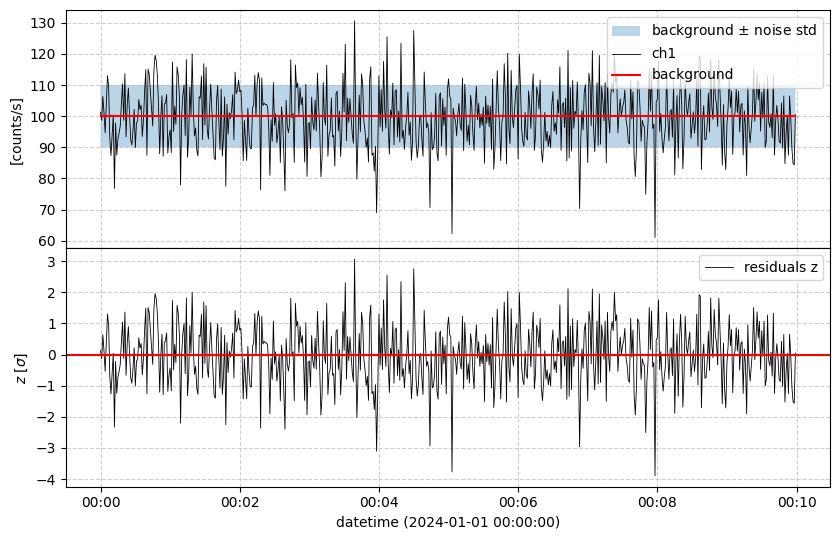

In [3]:
vt.plot_data_example(df, cols[0], 0, 600);

## 2. Pure Gaussian noise

Before looking for signals we need to know what each detector does when there is nothing to find: everything the trigger reports on pure noise is a false alarm.

In [4]:
channel_sets = {"1 channel": cols[:1], "2 channels": cols[:2], f"{N_CHANNELS} channels": cols}
noise = run_all("noise", Z, FREE, channel_sets)
rerun = {det: cached(f"noise, false alarms of {det}", vt.false_alarms_by_threshold,
                     det, Z, cols, channel_sets, RERUN_THRESHOLDS, resets) for det in vt.NEEDS_THRESHOLD}

# false alarms per day against the threshold, and the threshold giving 1 false alarm per day
false_alarms = {n: {det: pd.Series(vt.false_alarms_per_day(noise[det][n], THRESHOLDS, resets), index=THRESHOLDS)
                    for det in FREE} for n in channel_sets}
for n in channel_sets:
    for det in vt.NEEDS_THRESHOLD:
        false_alarms[n][det] = pd.Series(rerun[det][n], index=RERUN_THRESHOLDS)
thresholds = {det: vt.threshold_at_rate(rates.index, rates) for det, rates in false_alarms[f"{N_CHANNELS} channels"].items()}

**What the significance looks like.** 15 minutes of noise in one channel, with the threshold of each detector that gives 1 false alarm per day (dash-dot, computed below).

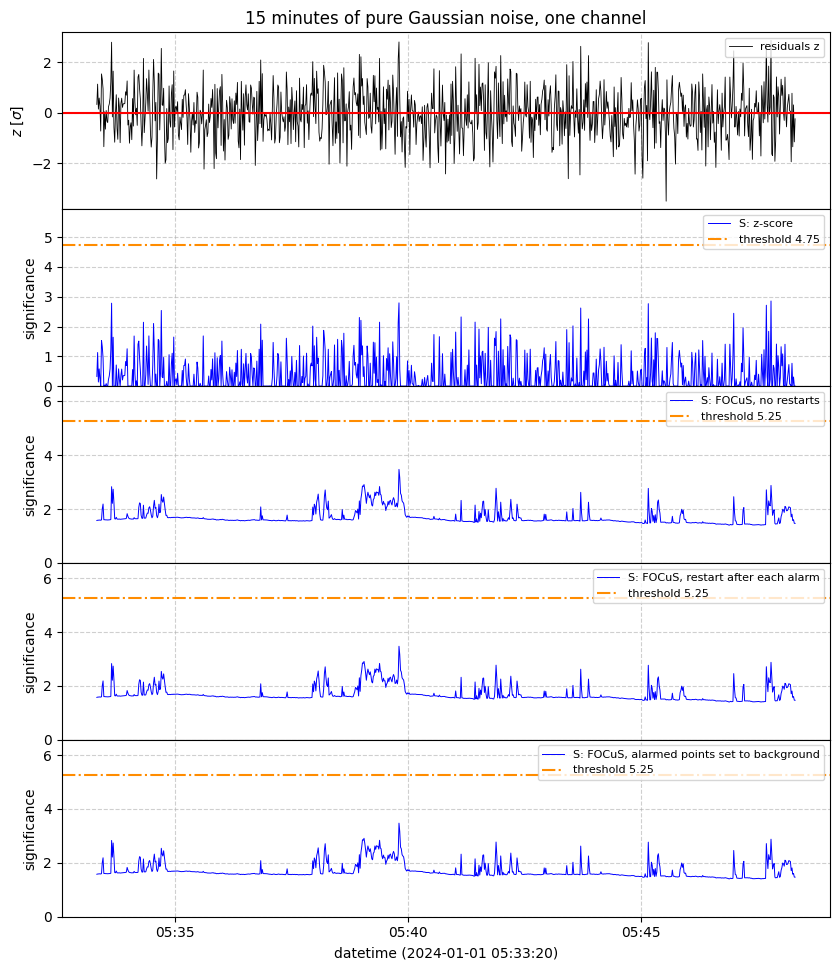

In [5]:
lo, hi = 20_000, 20_900
traces = {det: vt.significance(det, Z[0, :hi], threshold=thresholds[det])[lo:]  # from the beginning of the data
          for det in vt.DETECTORS}
vt.plot_significance_panels(times[lo:hi], Z[0, lo:hi], traces, thresholds, "15 minutes of pure Gaussian noise, one channel");

- The **z-score** is the residual itself, with negative values set to 0 (we look for excesses only).
- **FOCuS** takes, at every second, the best of all the stretches that end there, so it is never below the z-score. On pure noise it never goes back to 0: among so many stretches, some always look a bit high (here it stays between about 1.5 and 3.5).
- **FOCuS with restarts** and **FOCuS with alarmed points set to background** are identical to FOCuS without restarts: they differ from it only after an alarm, and in these 15 minutes there is none.

**A significance is not a number of sigmas.** For each detector, the fraction of the seconds (one channel, 30 days) in which the significance is above a given level. The last two detectors use their threshold for 1 false alarm per day. For the z-score this fraction is exactly the Gaussian probability $P(z > \mathrm{level})$ (dashed line).

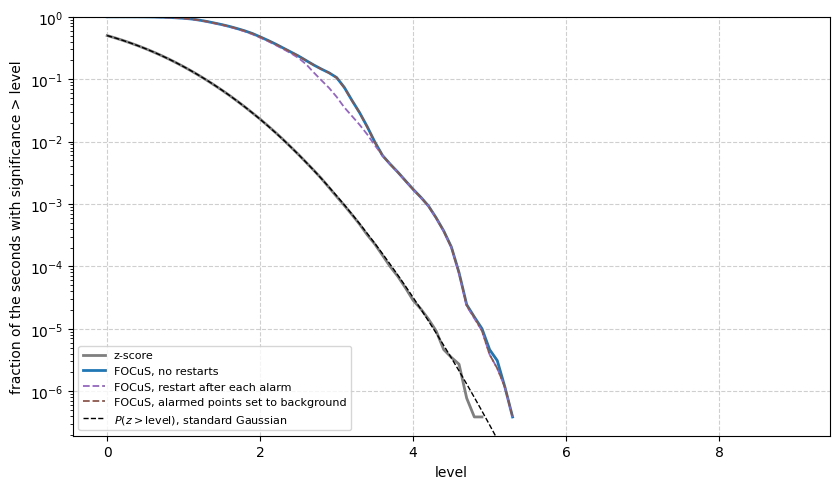

In [6]:
levels = np.arange(0, 9.01, 0.1)
one_channel = {det: vt.significance(det, Z[0], threshold=thresholds[det]) for det in vt.DETECTORS}
vt.plot_exceedance(levels, one_channel);

The z-score follows the Gaussian curve exactly, as it must. FOCuS lies above it: since it picks the best of many stretches every second, it goes over 4 about 50 times more often than a single Gaussian value, and over 5 about 16 times more often. A FOCuS significance of 5 is therefore not a 5σ fluctuation, and this is why the thresholds below are chosen from the number of false alarms, not read as numbers of sigmas.

FOCuS with restarts (dashed purple) lies on FOCuS without restarts, except between about 2.5 and 3.5, where it is a little lower. In this channel there was only one false alarm in 30 days, on day 20, caused by a long stretch of slightly high noise. For about a day after it, FOCuS without restarts stayed around 3, because it still remembered that stretch; FOCuS with restarts had forgotten it. FOCuS with alarmed points set to background (dashed brown) lies on FOCuS without restarts: it forgot only the few seconds that raised the alarm, not the stretch.

**How often does each detector cross a threshold?** The trigger fires when any channel is over threshold, and crossings closer than 60 s count as one event. On pure noise every event is a false alarm. For the z-score the expected rate is known exactly: every second, each of the $N$ channels exceeds a threshold $t$ with probability $P(z > t)$, so the expected number of false alarms per day is $N \times 86400 \times P(z > t)$ (dashed line), and agreement with it checks the counting itself. At very low thresholds the trigger is on most of the time and the crossings merge into a few long events, so the curves fall again on the left: only their right-hand part matters. The last two detectors change their memory after every alarm, so their significance depends on the threshold and they have to be run again for every threshold: to save time this is done only for thresholds between 4 and 6 (dashed lines).

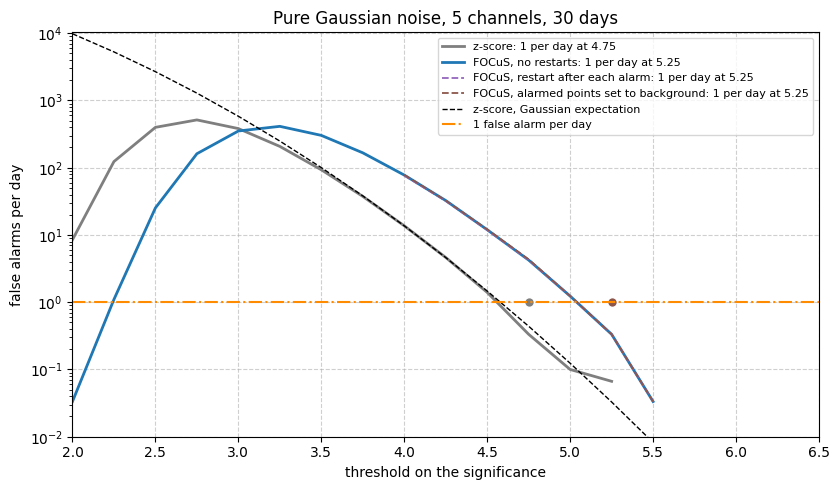

In [7]:
theory = pd.Series(N_CHANNELS * 86_400 * norm.sf(THRESHOLDS), index=THRESHOLDS)
vt.plot_false_alarms(false_alarms[f"{N_CHANNELS} channels"], thresholds, theory,
                     f"Pure Gaussian noise, {N_CHANNELS} channels, {DAYS} days");

The threshold that gives 1 false alarm per day, and how it grows with the number of channels (more channels, more chances for the noise to go over threshold somewhere):

In [8]:
pd.DataFrame({n: {det: vt.threshold_at_rate(r.index, r) for det, r in rates.items()}
              for n, rates in false_alarms.items()}).rename_axis("threshold for 1 false alarm/day")

,1 channel,2 channels,5 channels
threshold for 1 false alarm/day,,,
z-score,4.25,4.5,4.75
"FOCuS, no restarts",4.75,5.0,5.25
"FOCuS, restart after each alarm",4.75,5.0,5.25
"FOCuS, alarmed points set to background",4.75,5.0,5.25


- For the z-score the counted false alarms follow the Gaussian expectation (dashed line): the counting works. Its threshold for 1 false alarm per day over 5 channels is 4.75 (the Gaussian value is 4.58; the thresholds are scanned in steps of 0.25).
- FOCuS needs a threshold only 0.5 higher, 5.25: this is the price of looking at all the stretches instead of single seconds.
- The two versions of FOCuS that change their memory after an alarm have the same false alarms (their dashed lines lie on the blue one) and the same thresholds as FOCuS without restarts: on pure noise alarms are so rare that what happens after them hardly matters.
- From 1 to 5 channels, every threshold grows by 0.5.

**The three versions of FOCuS, threshold by threshold:** false alarms per day on the same noise, $N$ channels.

In [9]:
rates = false_alarms[f"{N_CHANNELS} channels"]
pd.DataFrame({det: rates[det].loc[RERUN_THRESHOLDS] for det in ("FOCuS, no restarts", *vt.NEEDS_THRESHOLD)}
             ).rename_axis("false alarms/day at threshold").round(2)

,"FOCuS, no restarts","FOCuS, restart after each alarm","FOCuS, alarmed points set to background"
false alarms/day at threshold,,,
4.00,77.80,76.67,78.33
4.25,32.53,32.03,32.43
4.50,11.97,11.87,12.10
4.75,4.23,4.23,4.33
5.00,1.23,1.23,1.23
5.25,0.33,0.33,0.33
5.50,0.03,0.03,0.03
5.75,0.00,0.00,0.00
6.00,0.00,0.00,0.00


From 5.0 up the three versions of FOCuS have exactly the same false alarms: on pure noise the significance goes over these thresholds so rarely that what happens after an alarm changes nothing. Between 4 and 4.75, where there are many false alarms per day, they differ by at most a few percent: FOCuS with restarts has about 1% fewer, because after an alarm it forgets the stretch of noise that caused it; FOCuS with alarmed points set to background keeps that stretch and has up to 2% more. All three have the same threshold, 5.25 for 1 false alarm per day.

## 3. Noise plus injected signals

We now add signals of known shape and strength to the same noise. Five shapes, here with example durations: a **spike** of one second; a **box**, a constant excess for 5 to 300 s; a **fred**, fast rise and exponential decay, the typical light curve of a gamma-ray burst (10 to 600 s); a slow **gaussian** bump (1 to 30 min); a **triangle**, slow rise and slow fall (1 to 30 min).

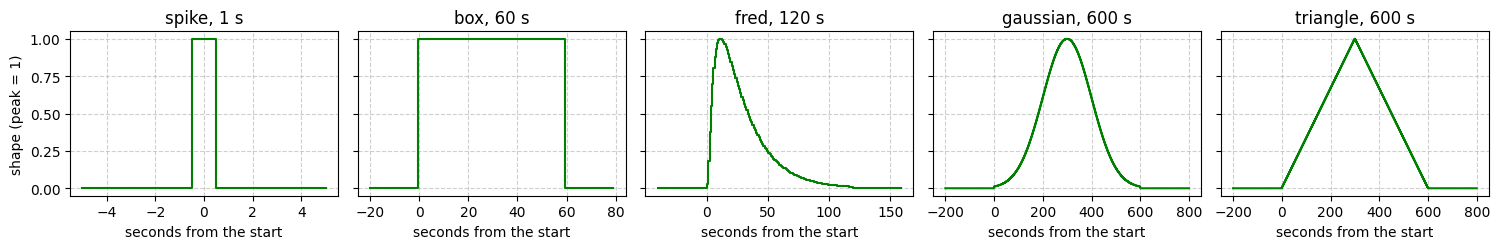

In [10]:
vt.plot_anomaly_shapes({"spike": 1, "box": 60, "fred": 120, "gaussian": 600, "triangle": 600});

Each signal has a **strength**: the z-score of its average excess over its duration, in the channel where it is strongest,

$$\mathrm{strength} = \frac{\sum_{\mathrm{signal}} \mathrm{excess}}{\sqrt{\mathrm{duration}}}, \qquad \mathrm{excess\ in\ units\ of\ } \sigma.$$

It is the significance that an ideal detector, one that knows exactly when the signal starts and ends, would measure on average. Strengths are drawn between 3 and 30, uniformly on a logarithmic scale, so that short and long signals cover the same range of difficulty. Each signal hits 1 to 3 channels with random relative weights; the strongest channel has weight 1. 12 signals per day are placed at random times, at least 10 minutes apart.

In [11]:
anomalies = random_anomalies(12 * DAYS, len(df), cols, n_groups=(1, 3), z_range=(3, 30), margin=120,
                             min_gap=600, seed=SEED + 1)
data, truth = inject(df, anomalies, std_suffix="_std")  # amplitudes in units of the noise std
truth["strongest"] = [a.channels[int(np.argmax(a.weights))] for a in anomalies]
Z_inj = vt.residuals(data, cols)
signals = run_all("noise with signals", Z_inj, list(vt.DETECTORS), {"all channels": cols}, thresholds)
print(f"{len(truth)} signals:", truth["kind"].value_counts().to_dict())
truth[["kind", "duration", "channels", "weights", "z_peak_channel", "start_datetime"]].head()

360 signals: {'spike': 78, 'fred': 74, 'triangle': 72, 'gaussian': 69, 'box': 67}


,kind,duration,channels,weights,z_peak_channel,start_datetime
0,gaussian,104,ch2,1,5.509976,2024-01-01 01:30:50+00:00
1,gaussian,117,ch2,1,26.324490,2024-01-01 02:06:42+00:00
2,gaussian,140,ch5/ch1,1/0.735,5.597128,2024-01-01 05:14:34+00:00
3,box,8,ch1/ch4/ch2,0.587/0.598/1,5.937448,2024-01-01 07:05:22+00:00
4,triangle,265,ch4/ch3/ch2,1/0.999/0.635,10.008153,2024-01-01 07:41:52+00:00


One example per shape, with strength close to 10. Top: the residuals of the strongest channel with the injected shape (green) and the injection interval (yellow band between green lines, as catalog events in `tslies.plotter`). Bottom: the significance of each detector, with its threshold for 1 false alarm per day (dash-dot, same colour).

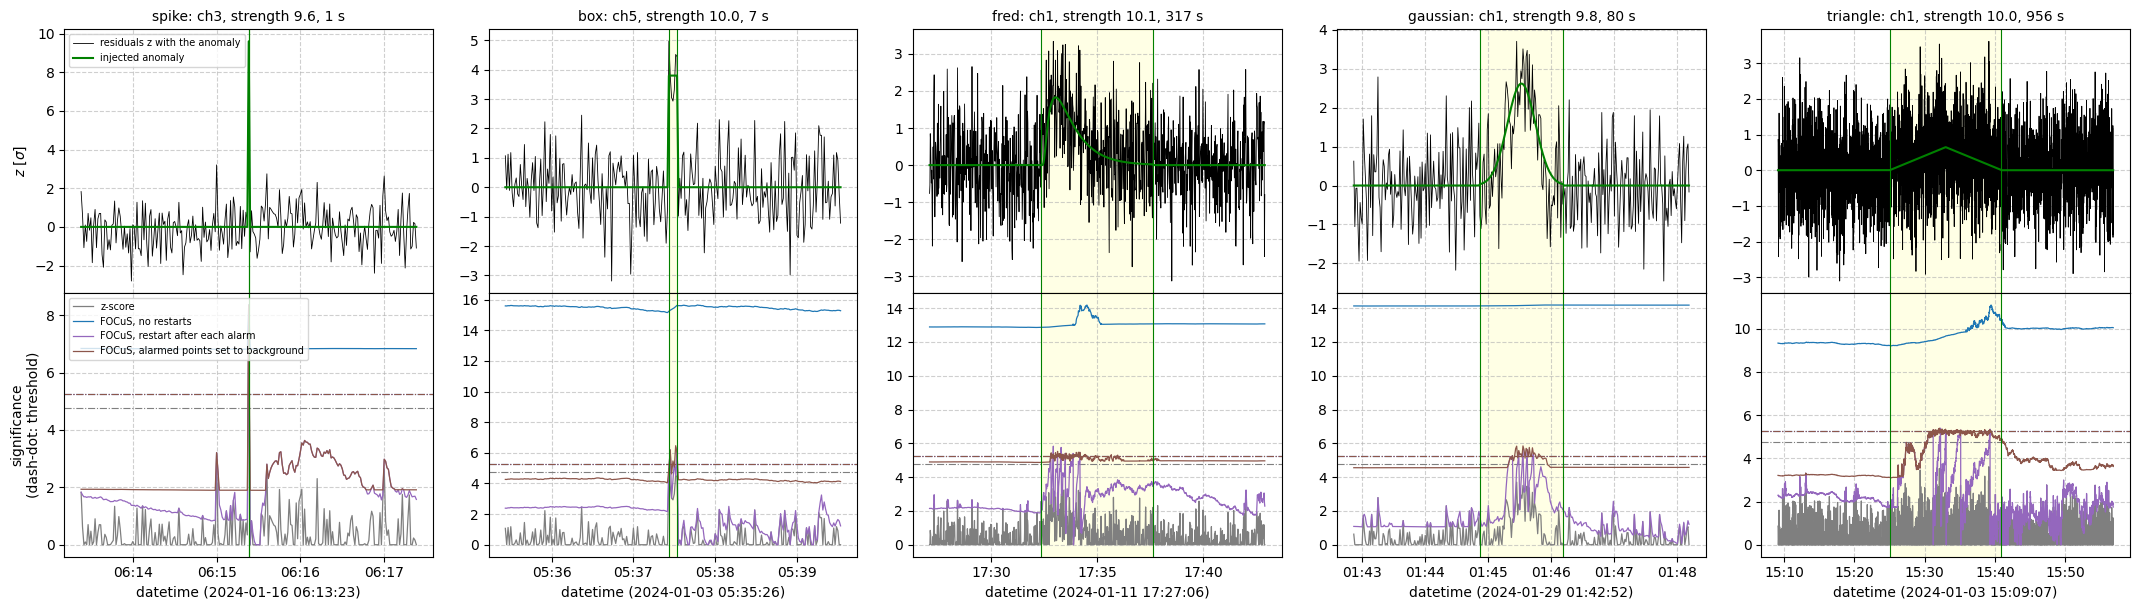

In [12]:
vt.plot_injection_examples(times, Z, Z_inj, cols, truth, thresholds, resets);

- **FOCuS without restarts** (blue) is already above its threshold before every signal (between about 7 and 15): it still remembers strong signals that came hours earlier in the data (see the next plot). A new signal only adds a small bump, and no new event can start, because the trigger is already on.
- **FOCuS with restarts** (purple) starts from the level of the noise and goes over its threshold during every signal. After each alarm it forgets everything and starts again, so during a slow signal it goes up and down around the threshold (3 to 7 alarms per signal here, highest values between 5.4 and 6.3): a strong, slow signal shows up as a series of alarms, not as a high peak. A spike, which arrives all at once, still gives a high peak (8.4 here, the z-score of that second).
- **FOCuS with alarmed points set to background** (brown) is already between 2 and 5 before every signal, higher than FOCuS with restarts: it keeps the memory of the earlier signals, cut just below the threshold. During the slow signals it lies flat on the threshold, with many more alarms than FOCuS with restarts (62 against 7 during the fred, 108 against 5 during the triangle), and after them it stays high: after the fred it is still close to the threshold at the end of the plot.
- The **z-score** sees the spike and, for one second only, the short box (4.96 against a threshold of 4.75). For the slower signals the excess of each single second is small, even when the whole signal is strong.

**The memory of FOCuS.** Without restarts, FOCuS keeps looking at all the stretches since the beginning of the data. After a strong, long signal, the stretch that contains it keeps a large sum, and its significance, sum / √length, falls only like 1 / √(time elapsed). Below: 6 hours of noise with a single signal of strength 30 lasting 30 minutes, from 01:00 to 01:30 (green lines and yellow band). In each panel, the red lines and band are the events found by that detector, computed as `Trigger` does: each alarm marks the stretch that raised it, from the estimated start of the change to the alarm, and stretches closer than 60 s form one event.

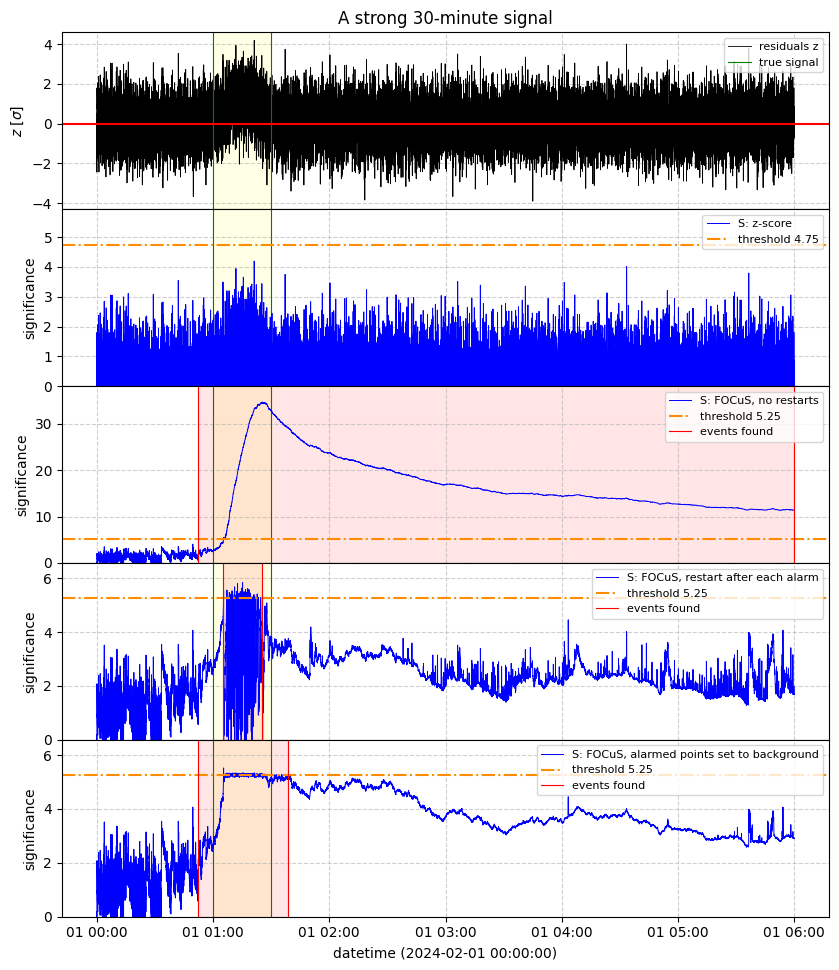

In [13]:
rng = np.random.default_rng(SEED + 2)
z_demo = rng.standard_normal(6 * 3600)
shape = profile("triangle", 1800)
z_demo[3600:5400] += 30 * np.sqrt(1800) / shape.sum() * shape  # strength 30
t_demo = pd.date_range("2024-02-01", periods=len(z_demo), freq="s", tz="UTC").to_numpy()
traces = {det: vt.significance(det, z_demo, threshold=thresholds[det]) for det in vt.DETECTORS}
events = {det: vt.detector_events(det, z_demo, thresholds[det]) for det in vt.DETECTORS}
vt.plot_significance_panels(t_demo, z_demo, traces, thresholds, "A strong 30-minute signal",
                            events=events, signal=(3600, 5399));

- **Without restarts**, FOCuS climbs to 35 and is still at 11 at the end of the plot, more than 4 hours after the end of the signal: all this time the trigger stays on, and any other signal would go unnoticed. Its event runs from 00:52 to the end of the data. It even starts 8 minutes before the signal: hours later the best stretch is so long that adding a few minutes of slightly high noise from before the signal makes it a little more significant. Repeating the test on longer stretches of noise (10 trials), it stays above its threshold for 9 to 34 hours after the end of the signal. This is what happens in the examples above.
- **With restarts**, FOCuS raises a series of alarms (46 here) during the signal and none after it, without any window or duration to choose. Its event runs from 01:05 to 01:25, inside the signal: the triangle starts and ends gently, so its first and last minutes cannot be told from the noise.
- **With alarmed points set to background**, FOCuS lies flat on the threshold while the signal lasts (703 alarms instead of 46) and raises a few more alarms up to 9 minutes after its end, so its event runs from 00:52 to 01:39: it ends 9 minutes after the signal and, like FOCuS without restarts, starts 8 minutes before it. Its memory is cut, not emptied: it stays between 4 and 5 for about an hour and a half after the end of the signal, and is still at 3 at the end of the plot, when FOCuS with restarts is back to the level of the noise.
- The **z-score** never reaches its threshold (highest value 4.2 against 4.75), so it finds no event: the signal is strong in total, but no single second is.

**Does the significance measure what it should?** For each signal, the highest significance reached in its strongest channel during the signal (and up to 60 s after it), against its strength. Each signal is measured on its own, with the detector started 10 minutes before it, so that earlier signals do not interfere. A detector that adds up the whole signal correctly gives points around the dashed line, with a scatter of about ±1 due to the noise. The last two detectors change their memory after each alarm, so during a signal their significance does not keep growing. The dash-dot lines are the thresholds for 1 false alarm per day.

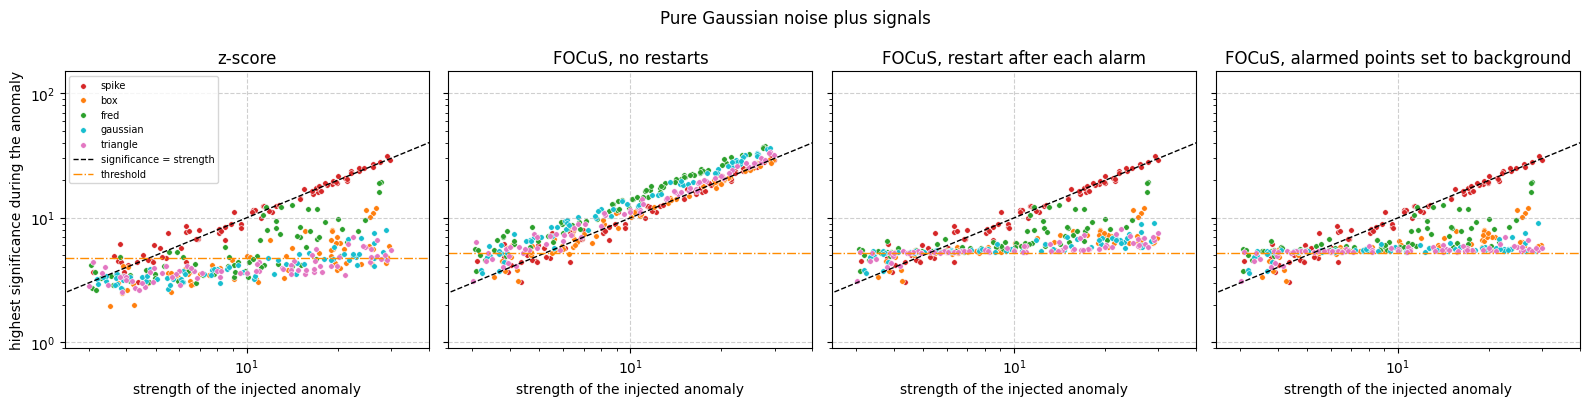

In [14]:
measured = {det: vt.measure_isolated(det, Z_inj, cols, truth, threshold=thresholds[det]) for det in vt.DETECTORS}
vt.plot_expected_vs_measured(truth, measured, "Pure Gaussian noise plus signals", thresholds);

- **FOCuS** measures what it should. For boxes and spikes the points lie on the dashed line. Freds, gaussians and triangles lie above it, by about 40%, 25% and 10%: their excess is concentrated around their peak, so a stretch shorter than the whole signal is more significant than the whole signal, and FOCuS finds it. These are exactly the values of the best stretch of each signal computed without noise (1.35, 1.23 and 1.09 times the strength, median by shape). At low strength all the points are a bit higher still, because there the noise counts more: the best stretch is the one where signal and noise together look highest.
- **FOCuS with restarts** and **FOCuS with alarmed points set to background** are identical to FOCuS without restarts up to the threshold, so they go over it for the same signals (87.5% of them, measured one by one). Above the threshold their highest value no longer grows with the strength: spikes, which arrive all at once, are still on the line, but for the slower signals the points stop just above the threshold (between 5.5 and 8, median by shape, for strengths above 10). With these two versions the significance tells that a signal is there, not how strong it is.
- The **z-score** is on the line only for spikes, which last one second. For the other shapes it measures only the excess of a single second: between a quarter and a half of the strength, for strengths above 10.

**How many signals does each detector find**, at the same false alarm rate, 1 per day (thresholds of section 2)? A signal counts as found if a new event starts between its start and 60 s after its end: a trigger that is already on because of an earlier signal does not count.

,z-score,"FOCuS, no restarts","FOCuS, restart after each alarm","FOCuS, alarmed points set to background"
found [%],,,,
box,39.0,3.0,90.0,88.0
fred,50.0,8.0,96.0,96.0
gaussian,25.0,7.0,88.0,88.0
spike,88.0,8.0,85.0,85.0
triangle,22.0,6.0,89.0,89.0


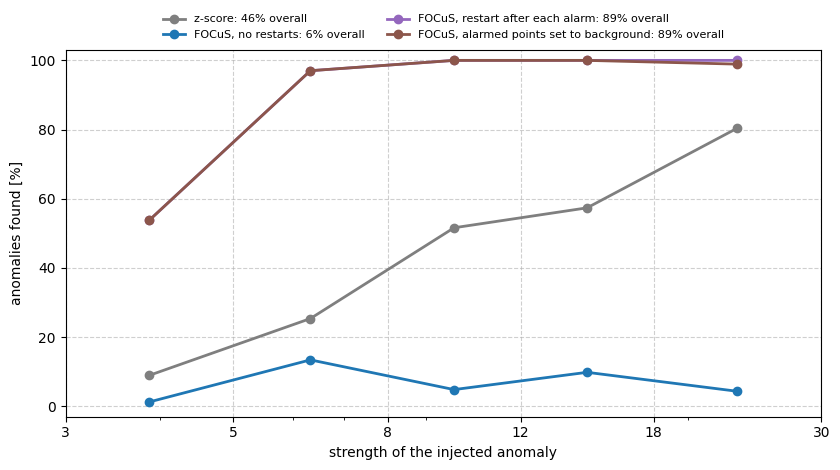

In [15]:
found = {det: vt.detected(signals[det]["all channels"], truth, thresholds[det], resets) for det in vt.DETECTORS}
vt.plot_found_fraction(truth, found);
pd.DataFrame({det: pd.Series(hit).groupby(truth["kind"]).mean() * 100 for det, hit in found.items()}).round(0).rename_axis("found [%]")

In [16]:
pd.DataFrame({det: {
    "threshold": thresholds[det],
    "signals found [%]": found[det].mean() * 100,
    "false alarms per day": vt.false_alarms_with_signals(signals[det]["all channels"], truth, thresholds[det], resets),
    "time with the trigger on [%]": (signals[det]["all channels"] > thresholds[det]).mean() * 100,
} for det in vt.DETECTORS}).T.round(2)

,threshold,signals found [%],false alarms per day,time with the trigger on [%]
z-score,4.75,45.83,0.27,0.03
"FOCuS, no restarts",5.25,6.39,0.00,95.64
"FOCuS, restart after each alarm",5.25,89.44,0.37,0.14
"FOCuS, alarmed points set to background",5.25,89.17,4.20,0.90


At the same false alarm rate, FOCuS restarting after each alarm finds 89% of the signals, against 46% for the z-score. It finds all the signals stronger than 8 and 97% of those between 5 and 8, whatever their shape; only below 5 does it miss about half of them. FOCuS without restarts finds only 6%: after the first strong signals its trigger is on 96% of the time, so new signals cannot start new events (and it has no false alarms only because it is always on). Only for spikes, which last one second, is the z-score as good as FOCuS, even slightly better (88% against 85%): there is nothing to add up, and FOCuS pays for its slightly higher threshold.

FOCuS with alarmed points set to background finds the same signals as FOCuS with restarts (89%), but with the signals present it raises 4.2 false alarms per day instead of 0.37, eleven times more, although on pure noise the two have the same. Its memory of the signals is cut just below the threshold, not emptied, and fades slowly: with a signal every couple of hours in some channel, it spends 82% of the time above 4 (FOCuS with restarts 3%), so a small fluctuation of the noise is enough to push it over the threshold.

**Grouped as `Trigger` groups them.** The counts above join the seconds over threshold that are less than 60 s apart. `Trigger` instead marks, for each alarm, the whole stretch that raised it, from the estimated start of the change to the alarm, and joins the marked stretches less than 60 s apart into events (section 4); the events are then paired with the signals by overlap (`match_events`). For a detector that keeps its memory these stretches can be very long, so the same alarms can give very different events.

In [17]:
grouped = {}
for det in vt.DETECTORS:
    events = pd.DataFrame(vt.grouped_events(det, Z_inj, thresholds[det], resets), columns=["start_index", "stop_index"])
    _, _, summary = match_events(events, truth)
    length = events["stop_index"] - events["start_index"] + 1
    longest = events.loc[length.idxmax()]
    grouped[det] = {
        "events": summary["n_events"],
        "signals found [%]": summary["efficiency"] * 100,
        "false alarms per day": summary["n_false"] / DAYS,
        "longest event [hours]": length.max() / 3600,
        "signals in the longest event": ((truth["start_index"] <= longest["stop_index"])
                                         & (truth["stop_index"] >= longest["start_index"])).sum(),
        "time covered by events [%]": length.sum() / len(df) * 100,
    }
pd.DataFrame(grouped).T.round(2)

,events,signals found [%],false alarms per day,longest event [hours],signals in the longest event,time covered by events [%]
z-score,175.0,45.83,0.30,0.02,1.0,0.06
"FOCuS, no restarts",2.0,100.00,0.00,717.98,359.0,99.72
"FOCuS, restart after each alarm",332.0,89.44,0.33,0.63,1.0,2.18
"FOCuS, alarmed points set to background",94.0,97.22,0.07,513.28,258.0,72.12


- **FOCuS with restarts** gives the same events as `Trigger` in section 4: 332 events, one for each of the 322 signals found plus 10 false alarms. The longest lasts 38 minutes, and all together they cover 2% of the time.
- **FOCuS without restarts**, after the first signals, marks stretches that reach back to them: it gives 2 events, the longest lasting 30 days with 359 of the 360 signals inside, covering almost all the time. By overlap it "finds" every signal, but it cannot say when any of them happened.
- **FOCuS with alarmed points set to background** is not much better. In channel 1 an alarm rests on a stretch 21 days long: the memory of all the earlier signals, never emptied. A single event covers those 21 days and 258 signals, and the events cover 72% of the time. Its 4.2 false alarms per day of the table above almost disappear here (0.07 per day) only because these long events swallow them.
- The **z-score** marks only the seconds over threshold, so its events are those of the counts above (the small differences come from pairing events and signals by overlap).

## 4. The same signals through `Trigger` and the TSLies plotter

The same test with the tools of the analyses. `Trigger` runs FOCuS restarting after each alarm, at the threshold of section 2, on the data with the signals, using the true background and noise standard deviation as background model. It marks as anomalous the stretch of data that raised each alarm, from the estimated start of the change to the alarm, and groups the stretches closer than 60 s into events. `match_events` compares the events with the injected signals: here every event that matches no signal is a real false alarm.

In [18]:
threshold = thresholds[restart]
trigger = Trigger(data, cols, [f"{c}_bkg" for c in cols], thresholds=threshold, trigger_type="focus",
                  std_cols=[f"{c}_std" for c in cols], units=vt.units(cols), latex_y_cols=vt.latex_labels(cols))
trigger.run(reset_condition=resets)
trigger.identify_and_merge_triggers(merge_interval=vt.MERGE_SECONDS)
truth_out, detections_out, summary = match_events(trigger.get_detections_df(), truth)
pd.Series({"threshold": threshold, "signals found [%]": summary["efficiency"] * 100, "events": summary["n_events"],
           "false alarms per day": summary["n_false"] / DAYS}).round(2).to_frame("Trigger, FOCuS")

,"Trigger, FOCuS"
threshold,5.25
signals found [%],89.44
events,332.00
false alarms per day,0.33


`Trigger` gives the same result: 89% of the signals found (322 of 360), with 0.33 false alarms per day. The successive alarms of a long signal are joined, so each signal found gives exactly one event: the 332 events are the 322 signals found plus 10 false alarms.

**When does the trigger fire, and where does it place the start of the signal?** For every signal found: the time from the start of the signal to its first alarm (left, with the duration of the signal as a black dash), and the difference between the start estimated by the trigger and the true start (right).

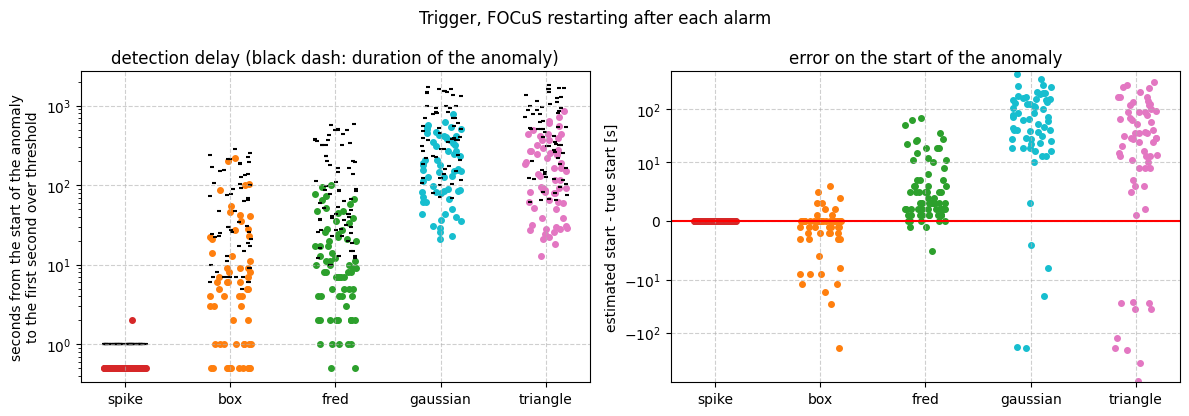

In [19]:
vt.plot_timing(truth_out, "Trigger, FOCuS restarting after each alarm");

- Spikes are detected in the second they happen (all but one, detected 2 s later), and their start is exact. A delay of 0 s is drawn at 0.5 s because of the logarithmic scale.
- All the other signals found are detected before their end.
- Boxes and freds are detected after a few seconds (median 5 s for boxes, 9 s for freds; 9 out of 10 within about 50 s), about a tenth of the way through the signal. The start of boxes is found within 10 s in 92% of the cases, often a few seconds early: the best stretch can include a few seconds of noise that happened to be high just before the signal. The start of freds is usually a few seconds late (median 3 s): a fred begins gently, and its first seconds are lost in the noise.
- The slow gaussians and triangles are detected after about 2 minutes (median; 8 out of 10 between half a minute and 8 minutes), about a third of the way through the signal. For the same reason as the freds, their estimated start is usually late, by a median of 1 minute for gaussians and 30 s for triangles; in 8% (gaussians) and 16% (triangles) of the cases it is early instead, because the noise just before the signal happened to be high.

Finally, two signals of strength close to 12 as `plot_anomalies` draws them. The injected signals are passed to `filter_from_catalog` as a catalog, so that they appear with green lines and a yellow band, like catalog events. In the significance panels, every time FOCuS goes over threshold it forgets everything and starts again, so during a signal its significance goes up and down around the threshold. The plotter writes the threshold as 5.25σ: as seen in section 2, it is not a number of sigmas.

Plotting anomalies:   0%|          | 0/2 [00:00<?, ?it/s]

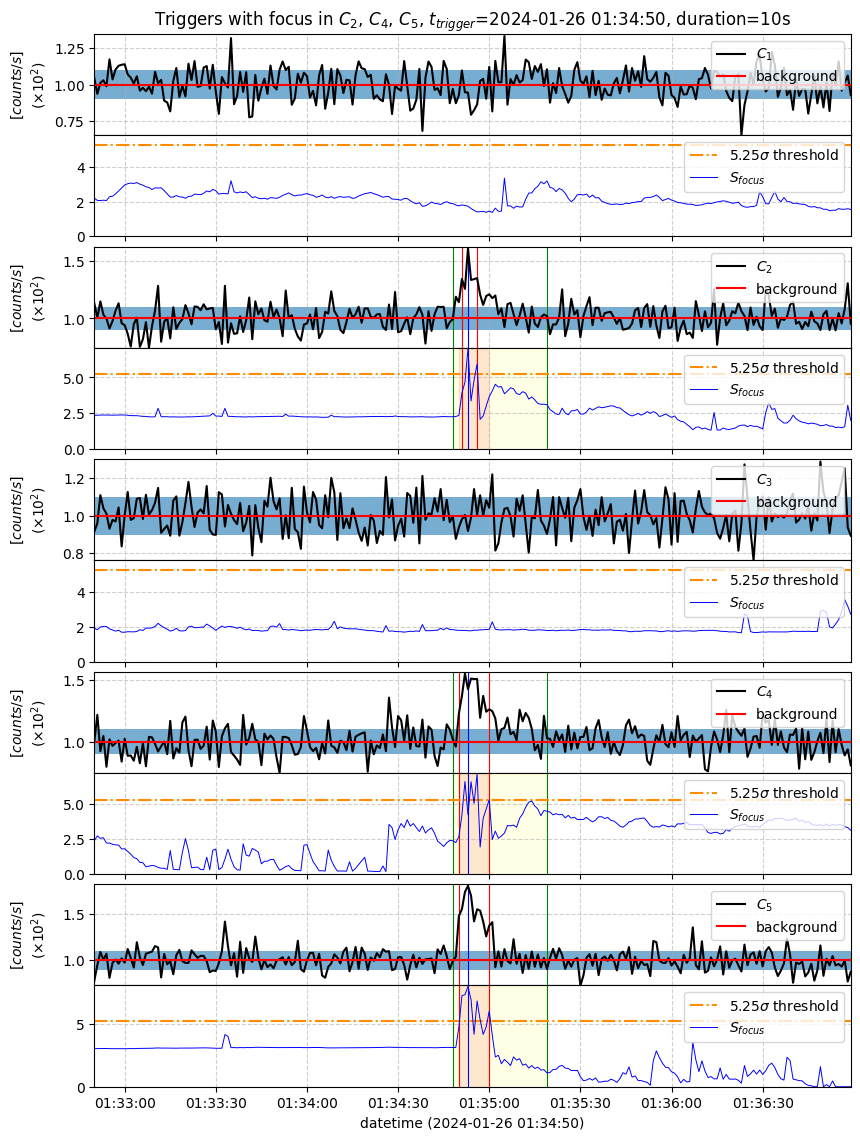

Plotting anomalies:  50%|█████     | 1/2 [00:04<00:04,  4.95s/it]

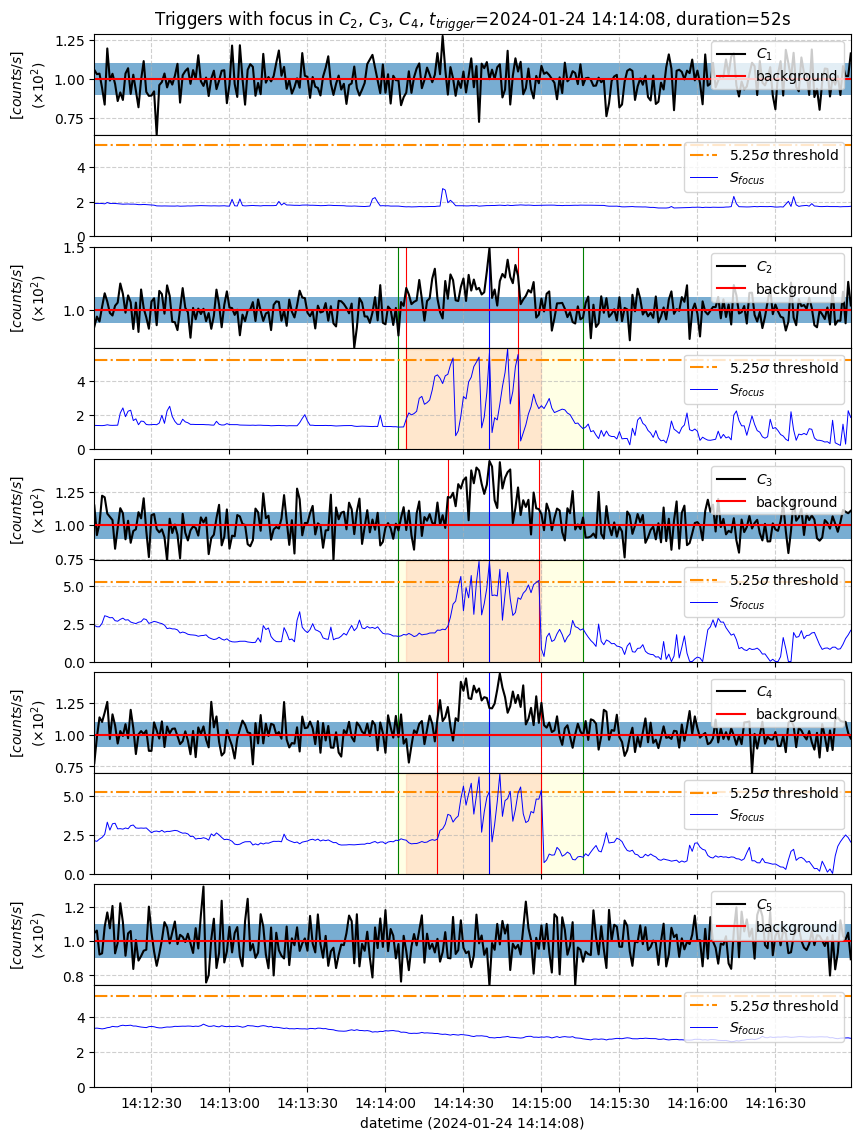

Plotting anomalies: 100%|██████████| 2/2 [00:09<00:00,  4.58s/it]


In [20]:
injected_catalog = pd.DataFrame({
    "NAME": truth["kind"] + "_" + truth["anomaly_id"].astype(str), "CAT_NAME": "INJECTED",
    "TRIGGER_TYPE": truth["kind"], "TIME": truth["start_datetime"],
    "TRIGGER_TIME": truth["peak_datetime"], "END_TIME": truth["stop_datetime"]})
matched, matched_events = trigger.filter_from_catalog(injected_catalog)
trigger.plot_anomalies(vt.pick_examples(matched_events, truth, ["fred", "gaussian"], strength=12), show=True)

## 5. Computation time

How long each detector takes on one channel, for data of growing length. The z-score is a single numpy operation. FOCuS processes one second at a time in Python: at each second it updates its list of candidate starts, which stays short (about ten candidates; at most 21 over a million seconds of noise), because a start that can never give the best stretch is discarded for good. Trying all the possible starts one by one, as in the definition, gives exactly the same significance (checked below), but its cost grows with the square of the length of the data, so it is timed on short series only. Each time is the best of three runs. The times depend on the computer and on what else is running on it; their ratios much less.

FOCuS gives exactly the significance of its definition: True


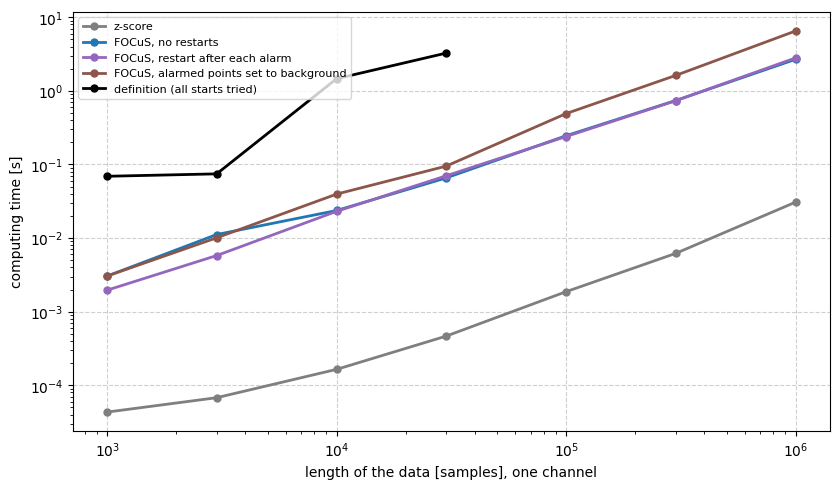

In [21]:
import time

def seconds(func, *args, repeat=3):
    """Best of a few runs, to reduce the effect of other programs running on the computer."""
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        func(*args)
        best = min(best, time.perf_counter() - t0)
    return best

z = Z[0]
print("FOCuS gives exactly the significance of its definition:",
      np.allclose(vt.brute_force_focus(z[:3000]), vt.significance("FOCuS, no restarts", z[:3000])))
lengths = [1_000, 3_000, 10_000, 30_000, 100_000, 300_000, 1_000_000]
compute = {det: {n: seconds(vt.significance, det, z[:n], None, thresholds[det]) for n in lengths} for det in vt.DETECTORS}
compute["definition (all starts tried)"] = {n: seconds(vt.brute_force_focus, z[:n]) for n in lengths if n <= 30_000}
vt.plot_compute_time(compute);

In [22]:
week = 7 * 86_400  # samples in one week of 1 s data
rows = {}
for name, values in compute.items():
    n = max(values)
    per_week = values[n] * (week / n) ** (2 if name.startswith("definition") else 1)  # quadratic for the definition
    rows[name] = {"microseconds per sample": values[n] / n * 1e6, "one week, one channel [s]": per_week,
                  "one week, 15 channels [min]": per_week * 15 / 60}
pd.DataFrame(rows).T.round(3)

,microseconds per sample,"one week, one channel [s]","one week, 15 channels [min]"
z-score,0.031,0.019,0.005
"FOCuS, no restarts",2.680,1.621,0.405
"FOCuS, restart after each alarm",2.801,1.694,0.423
"FOCuS, alarmed points set to background",6.507,3.936,0.984
definition (all starts tried),108.543,1323.437,330.859


The times depend on how busy the computer is: from one run of this notebook to another they changed by up to 70%, so the numbers below are the ranges seen; their ratios change much less.

- The **z-score** is by far the fastest, 0.01 to 0.03 µs per sample: a single numpy operation on the whole series.
- **FOCuS** costs 1.5 to 3 µs per sample, with or without restarts (the small difference between the two lines changes from run to run): about 100 times the z-score, because it goes through the data one second at a time in Python. **FOCuS with alarmed points set to background** costs about 1.5 times as much, because at every second it keeps a copy of its memory, in case it has to undo that second. All grow linearly with the length of the data (straight lines): for a week of one channel at one sample per second, FOCuS takes 1 to 2 s; for 15 channels, 15 to 30 s.
- Computing the same significance from its **definition**, trying every possible start one by one, gives exactly the same numbers, but its time grows with the square of the length (the black line is steeper): already 50 to 85 µs per sample on 30 000 samples and, extrapolating, 10 to 17 minutes for a week of one channel and 2.5 to 4.5 hours for 15 channels. Discarding for good the starts that can never give the best stretch is what makes looking at all the durations at once affordable.

## 6. Summary

In [23]:
pd.DataFrame({
    "threshold for 1 false alarm/day": thresholds,
    "signals found [%]": {det: hit.mean() * 100 for det, hit in found.items()},
}).round(2)

,threshold for 1 false alarm/day,signals found [%]
z-score,4.75,45.83
"FOCuS, no restarts",5.25,6.39
"FOCuS, restart after each alarm",5.25,89.44
"FOCuS, alarmed points set to background",5.25,89.17


In this fully controlled setting:

1. The counting of false alarms is right: for the z-score it matches the Gaussian expectation.
2. A significance is not a number of sigmas: at the same threshold, FOCuS gives more false alarms than a single-second z-score. Thresholds must be set from the false alarm rate: for 1 per day on 5 channels, 4.75 for the z-score and 5.25 for all the versions of FOCuS.
3. FOCuS measures exactly the significance of the best stretch of each signal, whatever its shape, without having to choose any duration. When it changes its memory after an alarm, it stops measuring at the threshold: it tells that a signal is there, not how strong it is.
4. FOCuS must restart after each alarm, as it is meant to. Without restarts it remembers a strong signal for many hours (9 to 34 after the strong signal of section 3) and misses almost all the following ones (6% found). With restarts it finds 89% of the signals at 1 false alarm per day, against 46% for the z-score, and detects them before their end.
5. Keeping the memory and setting only the alarmed seconds to background finds the same signals as restarting, but with signals present it gives 11 times more false alarms (4.2 per day instead of 0.37), and with the alarms grouped as `Trigger` groups them its events last up to 21 days: the memory of past signals is never emptied, only kept just below the threshold. Restarting after each alarm remains the better choice.
6. FOCuS costs 1.5 to 3 µs per sample and channel: under half a minute for a week of 15 channels.

Next step: the real data, where the residuals are not exactly Gaussian nor always independent, so the false alarm rates and the thresholds will have to be measured again.